In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
from voluntary_fixation.envs import TR,SAVE_ROOT, NUM_ROIS
import os
from scipy.stats import ttest_1samp


import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 17 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 17 # 軸だけ変更されます

In [2]:
num_masks = 3
num_sal_conditions = 2
p_critrion = 0.05/9/NUM_ROIS/num_sal_conditions/num_masks

def plot(scores_rois, ax, delay_list, baseline, ylim, title='', yscale='linear', ylabel='Mean correlation score'):

    for roi in range(NUM_ROIS):
        ax.plot(np.arange(len(delay_list)), scores_rois[roi], label=f'roi {roi}')
    ax.set_xlabel('Lag Δτ [sec]')
    ax.set_ylabel(ylabel)
    # ax.legend()
    ax.set_xticks(np.arange(len(delay_list)))
    ax.set_xticklabels(delay_list)
    ax.set_ylim(ylim)
    if title is not None:
        ax.set_title(title)
    ax.hlines(baseline, 0, len(delay_list)-1, colors='k', linestyles='dashed')
    ax.set_yscale(yscale)



def visualize_control(modality, remove_str, slice_, delays, label_mode='public'):
    # (w, w/o saliency) * 2
    csv_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_control2_strict_ree2', f'eval_specific{label_mode}', remove_str)
    print('csv_dir loaded from : ', csv_dir)
    raw_corr_filename = 'raw_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'
    stats_test_filename = 'p_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'

    p_value_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    p_value_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    across_time_significant_rois = []
    for i, delay in enumerate(delays):
        stats_test_df = pd.read_csv(os.path.join(csv_dir, stats_test_filename.format(delay=delay)))
        raw_df = pd.read_csv(os.path.join(csv_dir, raw_corr_filename.format(delay=delay)))
        raw_df = raw_df.groupby('roi').mean()
        p_value_series_w_sal[:, i] = stats_test_df['w_sal_corr_ttest'].values
        raw_corr_series_w_sal[:, i] = raw_df['w_sal_corr'].values
        p_value_series_wo_sal[:, i] = stats_test_df['wo_sal_corr_ttest'].values
        raw_corr_series_wo_sal[:, i] = raw_df['wo_sal_corr'].values
        if delay < 0:
            sig_rois = np.where(p_value_series_wo_sal[:, i]<p_critrion)[0]
            print(f'delay:{delay}', sig_rois, p_value_series_wo_sal[sig_rois, i]*2*NUM_ROIS*9*num_masks)
            print(raw_corr_series_wo_sal[sig_rois, i])
        across_time_significant_rois.append(np.where(p_value_series_wo_sal[:, i]<p_critrion)[0])

    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    plot(raw_corr_series_wo_sal, axes, delays, 0, [-0.1,0.4], title=None)
    plt.show()
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    plot(p_value_series_wo_sal, axes, delays, p_critrion, [1e-8, 1], title=None, yscale='log', ylabel='p-value')
    plt.show()
    # fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    # plot2(raw_corr_series_w_sal, axes, delays, 0, [-0.1,0.4], title=None)
    # plt.show()
    return np.unique(np.concatenate(across_time_significant_rois))

def visualize_control2(modality, remove_str, slice_, delays, label_mode='public'):
    csv_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_control2_strict_ree2', f'eval_specific{label_mode}', remove_str)
    raw_corr_filename = 'raw_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'
    stats_test_filename = 'p_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'

    p_value_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    p_value_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    for i, delay in enumerate(delays):
        stats_test_df = pd.read_csv(os.path.join(csv_dir, stats_test_filename.format(delay=delay)))
        raw_df = pd.read_csv(os.path.join(csv_dir, raw_corr_filename.format(delay=delay)))
        raw_df = raw_df.groupby('roi').mean()
        p_value_series_w_sal[:, i] = stats_test_df['w_sal_corr_ttest'].values
        raw_corr_series_w_sal[:, i] = raw_df['w_sal_corr'].values
        p_value_series_wo_sal[:, i] = stats_test_df['wo_sal_corr_ttest'].values
        raw_corr_series_wo_sal[:, i] = raw_df['wo_sal_corr'].values
        if delay < 0:
            sig_rois = np.where(p_value_series_w_sal[:, i]<p_critrion)[0]
            print(f'delay:{delay}', sig_rois, p_value_series_w_sal[sig_rois, i]*2*NUM_ROIS*9)
            print(raw_corr_series_w_sal[sig_rois, i])


    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    plot(raw_corr_series_w_sal, axes, delays, 0, [-0.1,0.4], title=None)
    plt.show()
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    plot(p_value_series_w_sal, axes, delays, p_critrion, [1e-8, 1], title=None, yscale='log', ylabel='p-value')
    plt.show()
    # fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    # plot2(raw_corr_series_w_sal, axes, delays, 0, [-0.1,0.4], title=None)
    # plt.show()



def compare_main_control(modality, control_modality, delay, main_roi, control_roi,
                         main_saliency_mode, control_saliency_mode, remove_str, slice_, label_mode='public'):
    csv_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_control2_strict_ree2', f'eval_specific{label_mode}', remove_str)
    main_raw_corr_filename = 'raw_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'
    control_raw_corr_filename = 'raw_value-delay{delay}' +f'-{control_modality}-by-{control_modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'

    main_raw_corr_df = pd.read_csv(os.path.join(csv_dir, main_raw_corr_filename.format(delay=delay)))
    control_raw_corr_df = pd.read_csv(os.path.join(csv_dir, control_raw_corr_filename.format(delay=delay)))

    main_raw_corrs = main_raw_corr_df.query(f'roi=={main_roi}')[main_saliency_mode+'_corr'].to_numpy()
    control_raw_corrs = control_raw_corr_df.query(f'roi=={control_roi}')[control_saliency_mode+'_corr'].to_numpy()

    p_value = ttest_1samp(main_raw_corrs - control_raw_corrs, 0)[1]
    print(f'delay:{delay}, roi{main_roi} vs {control_roi}, {main_saliency_mode} / {control_saliency_mode}', p_value)
    print('raw corr mean: ', np.mean(main_raw_corrs), np.mean(control_raw_corrs))
    print(['{:.3f}'.format(i) for i in main_raw_corrs-control_raw_corrs])
    return p_value

def compare_main_control2(modality, control_modality, delay_main, delay_control, main_roi, control_roi,
                         main_saliency_mode, control_saliency_mode, remove_str, slice_, label_mode='public'):
    csv_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_control2_strict_ree2', f'eval_specific{label_mode}', remove_str)
    main_raw_corr_filename = 'raw_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'
    control_raw_corr_filename = 'raw_value-delay{delay}' +f'-{control_modality}-by-{control_modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'

    main_raw_corr_df = pd.read_csv(os.path.join(csv_dir, main_raw_corr_filename.format(delay=delay_main)))
    control_raw_corr_df = pd.read_csv(os.path.join(csv_dir, control_raw_corr_filename.format(delay=delay_control)))

    main_raw_corrs = main_raw_corr_df.query(f'roi=={main_roi}')[main_saliency_mode+'_corr'].to_numpy()
    control_raw_corrs = control_raw_corr_df.query(f'roi=={control_roi}')[control_saliency_mode+'_corr'].to_numpy()

    p_value = ttest_1samp(main_raw_corrs - control_raw_corrs, 0)[1]
    print(f'delay:{delay_main}{delay_control}, roi{main_roi} vs {control_roi}, {main_saliency_mode} / {control_saliency_mode}', p_value)
    print('raw corr mean: ', np.mean(main_raw_corrs), np.mean(control_raw_corrs))
    print(['{:.3f}'.format(i) for i in main_raw_corrs-control_raw_corrs])
    return p_value



def plot_sig(sig_rois_across_time, scores_rois, ax, delay_list, baseline, ylim, title='', yscale='linear', ylabel='Mean correlation score',
             color=None):
    # num_sig_rois =
    for roi in sig_rois_across_time:
        if color is not None:
            c, label = color.get(roi, ('gray', None))
            if label is not None:
                ax.plot(np.arange(len(delay_list)), scores_rois[roi], label=label, color=c)
            else:
                ax.plot(np.arange(len(delay_list)), scores_rois[roi], color=c)
        else:
            ax.plot(np.arange(len(delay_list)), scores_rois[roi], label=f'roi {roi}')
    ax.set_xlabel('Lag Δτ [sec]')
    ax.set_ylabel(ylabel)
    # ax.legend()
    ax.set_xticks(np.arange(len(delay_list)))
    ax.set_xticklabels([d*TR for d in delay_list])
    ax.set_ylim(ylim)
    if title is not None:
        ax.set_title(title)
    ax.hlines(baseline, 0, len(delay_list)-1, colors='k', linestyles='dashed')
    ax.set_yscale(yscale)
    roi_id_in_color = list(color.keys()) if color is not None else []
    roi_id_in_color = [roi for roi in roi_id_in_color if roi <= NUM_ROIS ]
    # if color is not None:
    if len(roi_id_in_color)>0:
        ax.legend()

def visualize_control_significant(modality, remove_str, slice_, delays, label_mode='public', color=None, only_sig_rois=True):
    # (w, w/o saliency) * 2
    csv_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_control2_strict_ree2', f'eval_specific{label_mode}', remove_str)
    print('csv_dir loaded from : ', csv_dir)
    raw_corr_filename = 'raw_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'
    stats_test_filename = 'p_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'

    p_value_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    p_value_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    across_time_significant_rois = []
    for i, delay in enumerate(delays):
        stats_test_df = pd.read_csv(os.path.join(csv_dir, stats_test_filename.format(delay=delay)))
        raw_df = pd.read_csv(os.path.join(csv_dir, raw_corr_filename.format(delay=delay)))
        raw_df = raw_df.groupby('roi').mean()
        p_value_series_w_sal[:, i] = stats_test_df['w_sal_corr_ttest'].values
        raw_corr_series_w_sal[:, i] = raw_df['w_sal_corr'].values
        p_value_series_wo_sal[:, i] = stats_test_df['wo_sal_corr_ttest'].values
        raw_corr_series_wo_sal[:, i] = raw_df['wo_sal_corr'].values
        if delay < 0:
            sig_rois = np.where(p_value_series_wo_sal[:, i]<p_critrion)[0]
            print(f'delay:{delay}', sig_rois, p_value_series_wo_sal[sig_rois, i]*2*NUM_ROIS*9*num_masks)
            print(raw_corr_series_wo_sal[sig_rois, i])
        across_time_significant_rois.append(np.where(p_value_series_wo_sal[:, i]<p_critrion)[0])
    if only_sig_rois:
        sig_rois_across_time = np.unique(np.concatenate(across_time_significant_rois))
    else:
        sig_rois_across_time = np.arange(NUM_ROIS)
    print('significant rois across time:', sig_rois_across_time)
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    plot_sig(sig_rois_across_time, raw_corr_series_wo_sal, axes, delays, 0, [-0.1,0.4], title=None, color=color)

    savepath = os.path.join('figures', 'fig3_4', f'{modality}-Correlation_time_sequence_bold2feat_small_saliency.pdf')
    os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
    print(savepath)
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    plot_sig(sig_rois_across_time, p_value_series_wo_sal, axes, delays, p_critrion, [1e-8, 1], title=None, yscale='log', ylabel='p-value', color=color)
    plt.show()
    # fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    # plot2(raw_corr_series_w_sal, axes, delays, 0, [-0.1,0.4], title=None)
    # plt.show()

def visualize_control_significant2(modality, remove_str, slice_, delays, label_mode='public', color=None, only_sig_rois=True):
    csv_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_control2_strict_ree2', f'eval_specific{label_mode}', remove_str)
    raw_corr_filename = 'raw_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'
    stats_test_filename = 'p_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'

    p_value_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    p_value_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    across_time_significant_rois = []
    for i, delay in enumerate(delays):
        stats_test_df = pd.read_csv(os.path.join(csv_dir, stats_test_filename.format(delay=delay)))
        raw_df = pd.read_csv(os.path.join(csv_dir, raw_corr_filename.format(delay=delay)))
        raw_df = raw_df.groupby('roi').mean()
        p_value_series_w_sal[:, i] = stats_test_df['w_sal_corr_ttest'].values
        raw_corr_series_w_sal[:, i] = raw_df['w_sal_corr'].values
        p_value_series_wo_sal[:, i] = stats_test_df['wo_sal_corr_ttest'].values
        raw_corr_series_wo_sal[:, i] = raw_df['wo_sal_corr'].values
        if delay < 0:
            sig_rois = np.where(p_value_series_w_sal[:, i]<p_critrion)[0]
            print(f'delay:{delay}', sig_rois, p_value_series_w_sal[sig_rois, i]*2*NUM_ROIS*9)
            print(raw_corr_series_w_sal[sig_rois, i])
        across_time_significant_rois.append(np.where(p_value_series_w_sal[:, i]<p_critrion)[0])
    if only_sig_rois:
        sig_rois_across_time = np.unique(np.concatenate(across_time_significant_rois))
    else:
        sig_rois_across_time = np.arange(NUM_ROIS)
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    plot_sig(sig_rois_across_time, raw_corr_series_w_sal, axes, delays, 0, [-0.1,0.4], title=None, color=color)
    # plt.show()
    savepath = os.path.join('figures', 'fig3_4', f'{modality}-Correlation_time_sequence_bold2feat_large_saliency.pdf')
    os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
    print(savepath)
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    plot_sig(sig_rois_across_time, p_value_series_w_sal, axes, delays, p_critrion, [1e-8, 1], title=None, yscale='log', ylabel='p-value', color=color)
    plt.show()

masked_image
small saliency change
csv_dir loaded from :  ../../../../results/voluntary_fixation/bold2feat_control2_strict_ree2/eval_specificpublic/-remove_brightness-remove_empty_eyetrack0.5_0.7
delay:-3 [] []
[]
delay:-2 [] []
[]
delay:-1 [36] [0.02876109]
[0.10405364]
significant rois across time: [ 0  1  2  3  4  5  6  7 10 12 13 14 15 16 17 18 20 22 23 24 25 26 28 29
 32 33 34 35 36 37 38 39 42 43]
/home/kazu/shared_response/figures/fig3_4/masked_image-Correlation_time_sequence_bold2feat_small_saliency.pdf


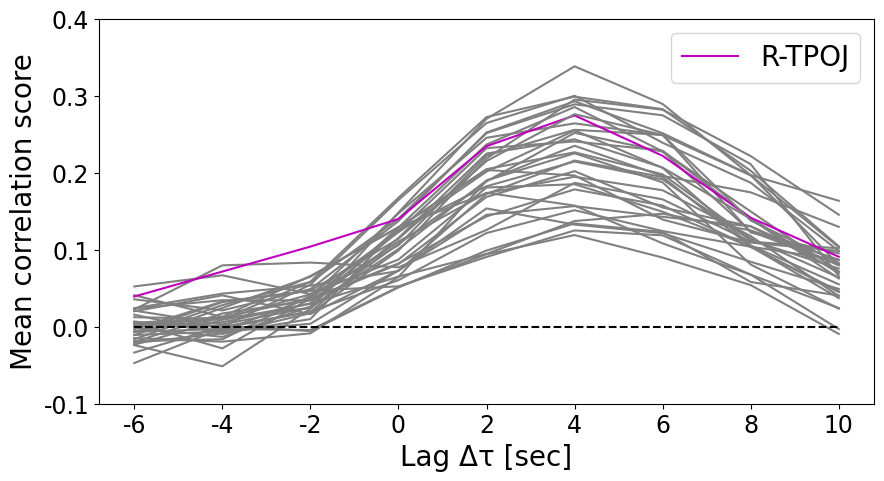

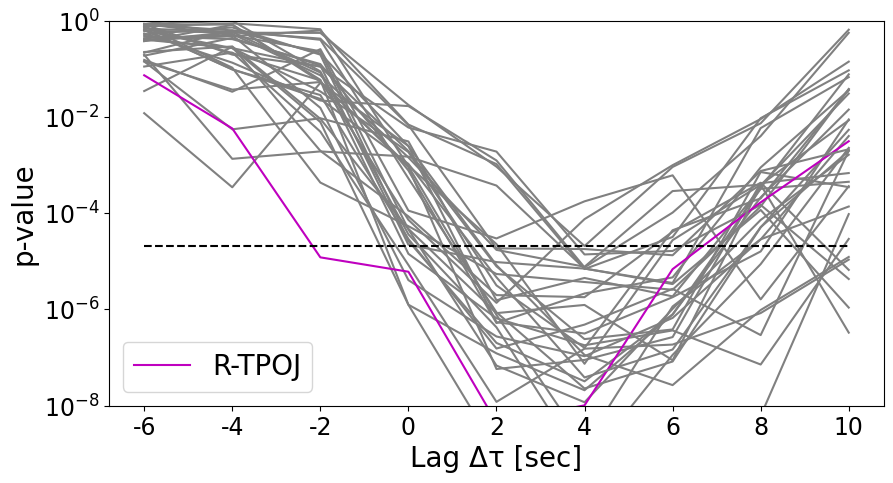

masked_image
large saliency change
delay:-3 [] []
[]
delay:-2 [] []
[]
delay:-1 [] []
[]
/home/kazu/shared_response/figures/fig3_4/masked_image-Correlation_time_sequence_bold2feat_large_saliency.pdf


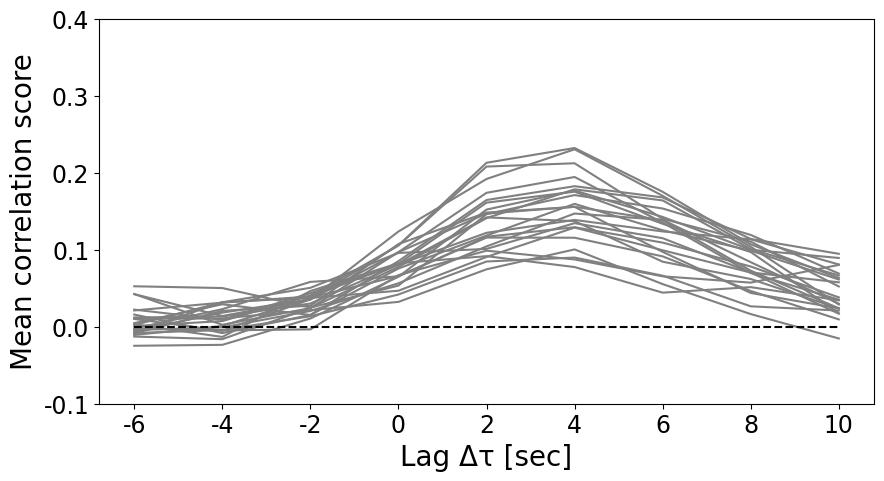

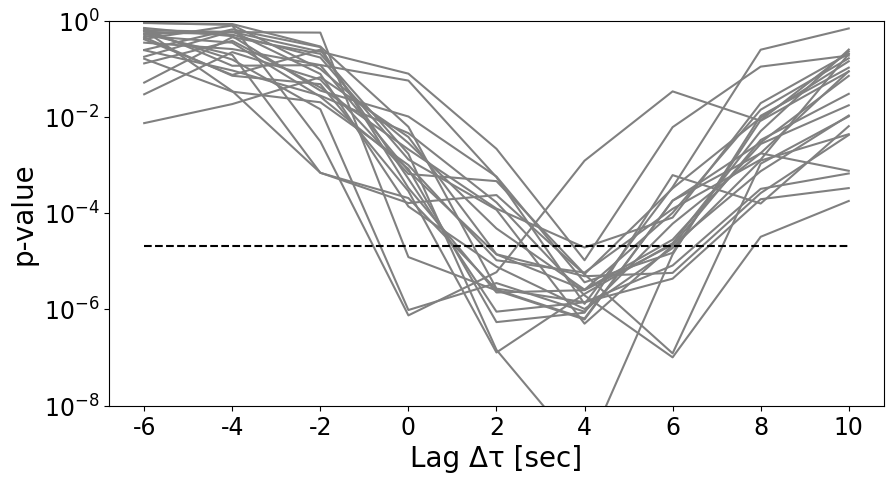

shuffled_masked_image2
small saliency change
csv_dir loaded from :  ../../../../results/voluntary_fixation/bold2feat_control2_strict_ree2/eval_specificpublic/-remove_brightness-remove_empty_eyetrack0.5_0.7
delay:-3 [] []
[]
delay:-2 [] []
[]
delay:-1 [] []
[]
significant rois across time: [ 1  2  3  4  7 16 18 22 23 26 43]
/home/kazu/shared_response/figures/fig3_4/shuffled_masked_image2-Correlation_time_sequence_bold2feat_small_saliency.pdf


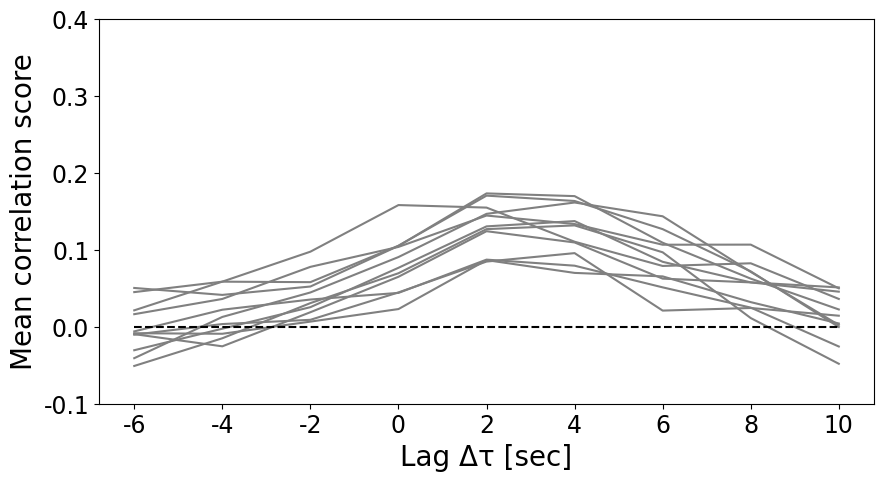

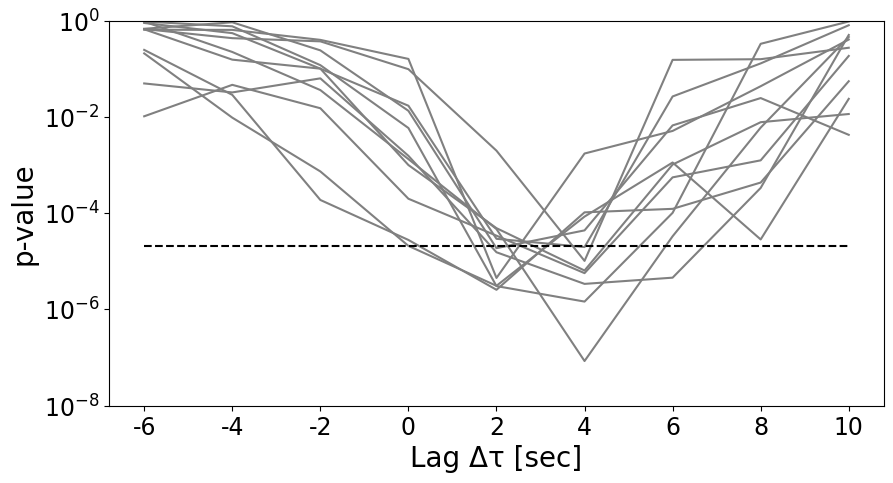

shuffled_masked_image2
large saliency change
delay:-3 [] []
[]
delay:-2 [] []
[]
delay:-1 [] []
[]
/home/kazu/shared_response/figures/fig3_4/shuffled_masked_image2-Correlation_time_sequence_bold2feat_large_saliency.pdf


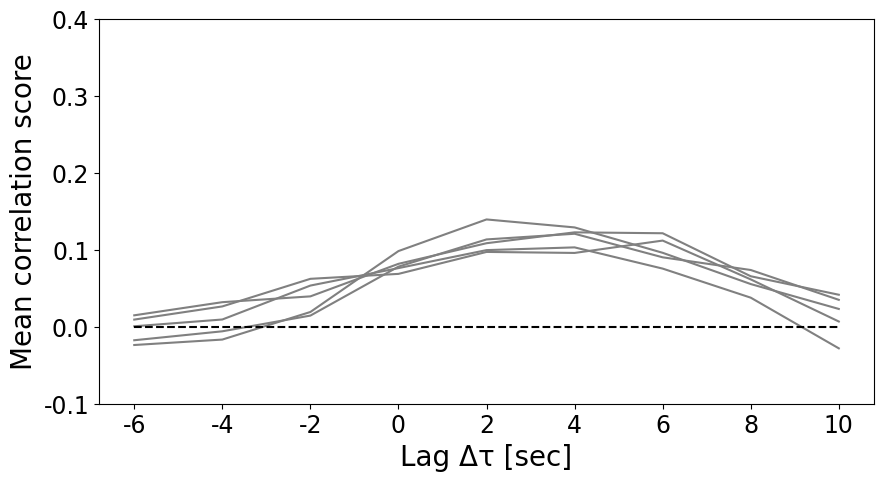

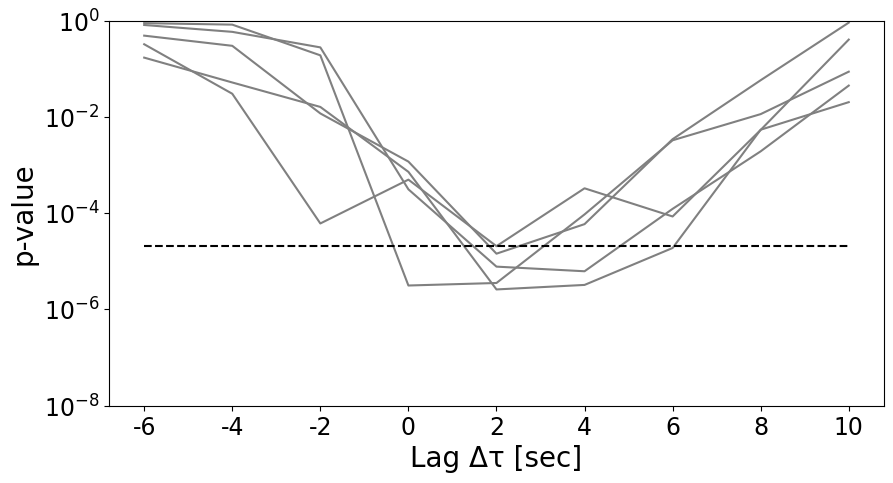

saliency_masked_image
small saliency change
csv_dir loaded from :  ../../../../results/voluntary_fixation/bold2feat_control2_strict_ree2/eval_specificpublic/-remove_brightness-remove_empty_eyetrack0.5_0.7
delay:-3 [] []
[]
delay:-2 [] []
[]
delay:-1 [] []
[]
significant rois across time: [ 0  1  2  3  4  7 10 13 14 15 16 18 21 22 23 24 25 26 36 38 39 40]
/home/kazu/shared_response/figures/fig3_4/saliency_masked_image-Correlation_time_sequence_bold2feat_small_saliency.pdf


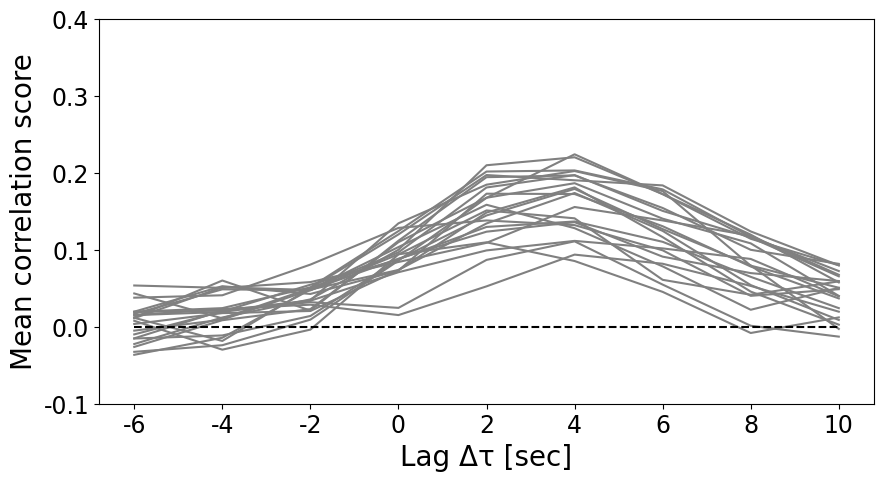

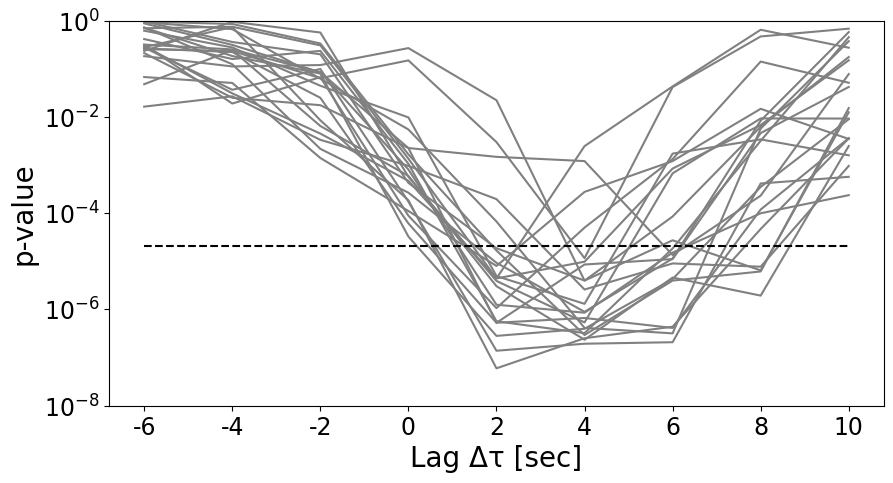

saliency_masked_image
large saliency change
delay:-3 [] []
[]
delay:-2 [] []
[]
delay:-1 [] []
[]
/home/kazu/shared_response/figures/fig3_4/saliency_masked_image-Correlation_time_sequence_bold2feat_large_saliency.pdf


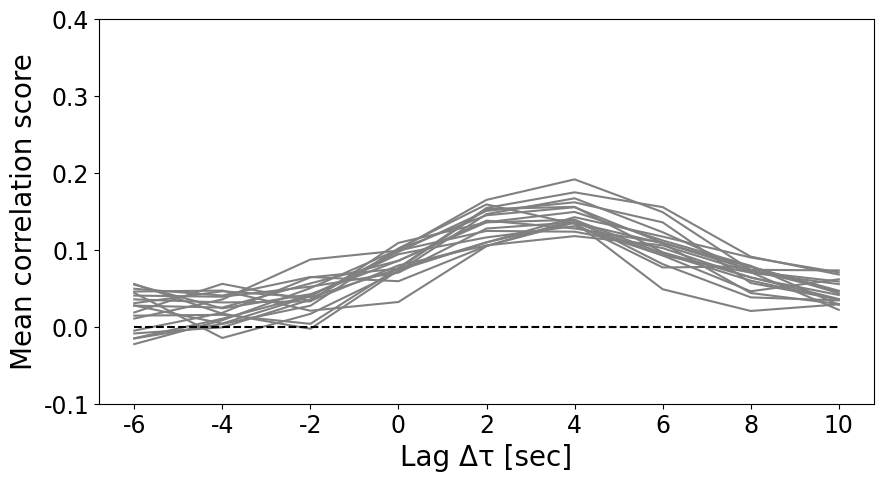

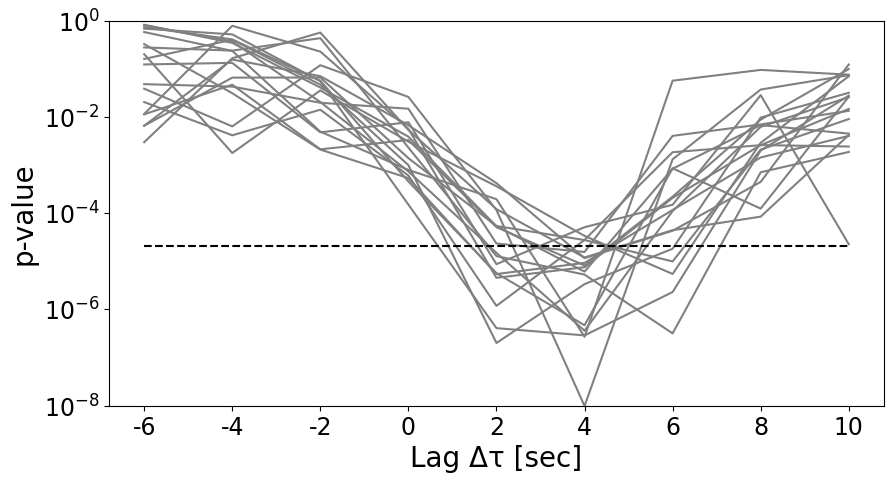

In [3]:

iou_th = 0.5
saliency_th = 0.7
delays = [-3, -2, -1, 0, 1, 2, 3, 4, 5]
slice_ = slice(4,5,1)
remove_brightness = True
remove_empty_eyetrack = True
remove_str = ''
if remove_brightness:
    remove_str += '-remove_brightness'
if remove_empty_eyetrack:
    remove_str += '-remove_empty_eyetrack'
remove_str += '{iou_th}_{saliency_th}'.format(iou_th=iou_th, saliency_th=saliency_th)
label_mode = 'public'

control_modalities = ['masked_image'] # , 'shuffled_masked_image2', 'reverse_masked_image', 'whole_image', 'saliency_masked_image'] # ['masked_image', 'shift_reverse_masked_image']
for modality in control_modalities:
    print('==========================')
    print(modality)
    print('small saliency change')
    print('==========================')
    visualize_control_significant(modality, remove_str, slice_, delays, label_mode=label_mode, color={36: ('m', 'R-TPOJ')}, only_sig_rois=True)
    print('==========================')
    print(modality)
    print('large saliency change')
    print('==========================')
    visualize_control_significant2(modality, remove_str, slice_, delays, label_mode=label_mode, color={90: ('m', 'R-TPOJ')}, only_sig_rois=True)

control_modalities = ['shuffled_masked_image2'] # , 'shuffled_masked_image2', 'reverse_masked_image', 'whole_image', 'saliency_masked_image'] # ['masked_image', 'shift_reverse_masked_image']
for modality in control_modalities:
    print('==========================')
    print(modality)
    print('small saliency change')
    print('==========================')
    visualize_control_significant(modality, remove_str, slice_, delays, label_mode=label_mode, color={90: ('m', 'R-TPOJ')}, only_sig_rois=True)
    print('==========================')
    print(modality)
    print('large saliency change')
    print('==========================')
    visualize_control_significant2(modality, remove_str, slice_, delays, label_mode=label_mode, color={90: ('m', 'R-TPOJ')}, only_sig_rois=True)

control_modalities = ['saliency_masked_image'] # , 'shuffled_masked_image2', 'reverse_masked_image', 'whole_image', 'saliency_masked_image'] # ['masked_image', 'shift_reverse_masked_image']
for modality in control_modalities:
    print('==========================')
    print(modality)
    print('small saliency change')
    print('==========================')
    visualize_control_significant(modality, remove_str, slice_, delays, label_mode=label_mode, color={90: ('m', 'R-TPOJ')}, only_sig_rois=True)
    print('==========================')
    print(modality)
    print('large saliency change')
    print('==========================')
    visualize_control_significant2(modality, remove_str, slice_, delays, label_mode=label_mode, color={90: ('m', 'R-TPOJ')}, only_sig_rois=True)


In [4]:
import cv2
import PIL.Image as Image
from nilearn import datasets, plotting, surface
from align_fmri.align_fmri.visualize_connectivity_utils import obtain_roi_surface
from align_fmri.align_fmri.atlas_definition import parc_path_lr, ROIs_22_LR
fsaverage = datasets.fetch_surf_fsaverage('fsaverage')
roi_masks, roi_v_lh_idxs, roi_v_rh_idxs, n_vertices_lh, n_vertices_rh = obtain_roi_surface(ROIs_22_LR, parcellation=parc_path_lr)

/home/kazu/envs/srm_env/lib/python3.10/site-packages/nilearn/maskers/nifti_masker.py:98: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
  2%|▏         | 1/44 [00:00<00:06,  6.94it/s]/home/kazu/envs/srm_env/lib/python3.10/site-packages/nilearn/masking.py:975: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(mask_img, unmasked, affine)
  5%|▍         | 2/44 [00:02<01:03,  1.52s/it]/home/kazu/envs/srm_env/lib/python3.10/site-packages/nilearn/masking.py:975: UserWarning: Data array used to create a new image contain

In [ ]:

num_delta_t = 9
P_CRITERION = p_critrion

def get_pvalues(modality, remove_str, slice_, delays, label_mode='public'):
    csv_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_control2_strict_ree2', f'eval_specific{label_mode}', remove_str)
    print('csv_dir loaded from : ', csv_dir)
    raw_corr_filename = 'raw_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'
    stats_test_filename = 'p_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'
    print('stats_test_filename from ', os.path.join(csv_dir.format(delay=-1), stats_test_filename))
    p_value_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    p_value_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    for i, delay in enumerate(delays):
        stats_test_df = pd.read_csv(os.path.join(csv_dir, stats_test_filename.format(delay=delay)))

        raw_df = pd.read_csv(os.path.join(csv_dir, raw_corr_filename.format(delay=delay)))
        raw_df = raw_df.groupby('roi').mean()
        p_value_series_w_sal[:, i] = stats_test_df['w_sal_corr_ttest'].values
        raw_corr_series_w_sal[:, i] = raw_df['w_sal_corr'].values
        p_value_series_wo_sal[:, i] = stats_test_df['wo_sal_corr_ttest'].values
        raw_corr_series_wo_sal[:, i] = raw_df['wo_sal_corr'].values
        # if delay <= 0:
        #     sig_rois = np.where(p_value_series_wo_sal[:, i]<p_critrion/NUM_ROIS)[0]
        #     print(f'delay:{delay}', sig_rois, p_value_series_wo_sal[sig_rois, i]*NUM_ROIS*num_delta_t*num_conditions)
        #     print(raw_corr_series_wo_sal[sig_rois, i])
    return p_value_series_wo_sal, p_value_series_w_sal, raw_corr_series_wo_sal, raw_corr_series_w_sal

def draw_hcp22(target_value, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap=None, vmin=-0.0, vmax=0.2):
    n_cluster = 22 # len(target_value)
    parcellation_left = np.zeros(n_vertices_lh, dtype=float)
    parcellation_right = np.zeros(n_vertices_rh, dtype=float)
    for cluster_roi in range(n_cluster):
        lh_idx = roi_v_lh_idxs[cluster_roi]
        rh_idx = roi_v_rh_idxs[cluster_roi]
        parcellation_left[lh_idx] = target_value[cluster_roi]
        parcellation_right[rh_idx] = target_value[cluster_roi+22]

    if cmap is None:
        cmap = 'black_red'
    # print('right', parcellation_right)
    # print('left', parcellation_left)
    plotting.plot_surf_roi(fsaverage['infl_left'], roi_map=parcellation_left, hemi='left', view='lateral', bg_map=fsaverage['sulc_left'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=True,  title=f"Left Hemisphere - lateral ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_left_lateral.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_left'], roi_map=parcellation_left, hemi='left', view='medial', bg_map=fsaverage['sulc_left'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=True,  title=f"Left Hemisphere - medial ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_left_medial.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_right'], roi_map=parcellation_right, hemi='right', view='lateral', bg_map=fsaverage['sulc_right'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=True,  title=f"Right Hemisphere - lateral ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_right_lateral.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_right'], roi_map=parcellation_right, hemi='right', view='medial', bg_map=fsaverage['sulc_right'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=True,  title=f"Right Hemisphere - medial ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_right_medial.png'))  # bg_on_data=True, darkness=.5
    print(os.path.join(prefix, f'_cluster_surface_left_lateral.png'))
    ll_path =  os.path.join(prefix, f'_cluster_surface_left_lateral.png')
    rl_path =  os.path.join(prefix, f'_cluster_surface_right_lateral.png')
    lm_path =  os.path.join(prefix, f'_cluster_surface_left_medial.png')
    rm_path =  os.path.join(prefix, f'_cluster_surface_right_medial.png')

    ll = Image.open(ll_path)
    rl = Image.open(rl_path)
    lm = Image.open(lm_path)
    rm = Image.open(rm_path)

    frame = np.concatenate([np.concatenate([ll, rl], axis=1),np.concatenate([lm, rm], axis=1)], axis=0)
    frames = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    cv2.imwrite(os.path.join(prefix, "concat.png"), frames)
    print(os.path.join(prefix, "concat.png"))


def concat_hcp22(target_value, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap=None, vmin=-0.0, vmax=0.2):
    n_cluster = 22 # len(target_value)
    parcellation_left = np.zeros(n_vertices_lh, dtype=float)
    parcellation_right = np.zeros(n_vertices_rh, dtype=float)
    for cluster_roi in range(n_cluster):
        lh_idx = roi_v_lh_idxs[cluster_roi]
        rh_idx = roi_v_rh_idxs[cluster_roi]
        parcellation_left[lh_idx] = target_value[cluster_roi]
        parcellation_right[rh_idx] = target_value[cluster_roi+22]

    if cmap is None:
        cmap = 'black_red'
    # print('right', parcellation_right)
    # print('left', parcellation_left)
    plotting.plot_surf_roi(fsaverage['infl_left'], roi_map=parcellation_left, hemi='left', view='lateral', bg_map=fsaverage['sulc_left'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=False,  title=f"Left Hemisphere - lateral ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_left_lateral.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_left'], roi_map=parcellation_left, hemi='left', view='medial', bg_map=fsaverage['sulc_left'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=False,  title=f"Left Hemisphere - medial ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_left_medial.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_right'], roi_map=parcellation_right, hemi='right', view='lateral', bg_map=fsaverage['sulc_right'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=False,  title=f"Right Hemisphere - lateral ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_right_lateral.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_right'], roi_map=parcellation_right, hemi='right', view='medial', bg_map=fsaverage['sulc_right'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=False,  title=f"Right Hemisphere - medial ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_right_medial.png'))  # bg_on_data=True, darkness=.5
    print('get image from ', os.path.join(prefix, f'_cluster_surface_left_lateral.png'))
    ll_path =  os.path.join(prefix, f'_cluster_surface_left_lateral.png')
    rl_path =  os.path.join(prefix, f'_cluster_surface_right_lateral.png')
    lm_path =  os.path.join(prefix, f'_cluster_surface_left_medial.png')
    rm_path =  os.path.join(prefix, f'_cluster_surface_right_medial.png')

    ll = Image.open(ll_path)
    rl = Image.open(rl_path)
    lm = Image.open(lm_path)
    rm = Image.open(rm_path)

    # crop images
    CROP_SIZE =(43, 70, 30, 80)  # left, upper, right, lower
    ll = ll.crop((CROP_SIZE[0], CROP_SIZE[1], ll.width-CROP_SIZE[2], ll.height-CROP_SIZE[3]))
    rl = rl.crop((CROP_SIZE[0], CROP_SIZE[1], rl.width-CROP_SIZE[2], rl.height-CROP_SIZE[3]))
    lm = lm.crop((CROP_SIZE[0], CROP_SIZE[1], lm.width-CROP_SIZE[2], lm.height-CROP_SIZE[3]))
    rm = rm.crop((CROP_SIZE[0], CROP_SIZE[1], rm.width-CROP_SIZE[2], rm.height-CROP_SIZE[3]))


    frame = np.concatenate([ll, lm, rl, rm], axis=1)
    frames = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    cv2.imwrite(os.path.join(prefix, "concat_horizontal.png"), frames)
    print('save concate image to ', os.path.join(prefix, "concat_horizontal.png"))


In [6]:
# masked image
modality = 'masked_image'

delays = [-3, -2, -1, 0, 1, 2, 3, 4, 5]
slice_ = slice(4,5,1)
remove_brightness = True
remove_empty_eyetrack = True

remove_str = ''
if remove_brightness:
    remove_str += '-remove_brightness'
if remove_empty_eyetrack:
    remove_str += '-remove_empty_eyetrack'

remove_str += '{iou_th}_{saliency_th}'.format(iou_th=iou_th, saliency_th=saliency_th)


p_value_series_wo_sal, p_value_series_w_sal, raw_corr_series_wo_sal, raw_corr_series_w_sal = get_pvalues(modality, remove_str, slice_, delays, label_mode=label_mode)

binary_significant_mat = p_value_series_w_sal < P_CRITERION
for d, delay in enumerate(delays):
    signinficant_corr = []

    for roi in range(NUM_ROIS):
        if binary_significant_mat[roi, d]:
            signinficant_corr.append(raw_corr_series_w_sal[roi, d])
        else:
            signinficant_corr.append(np.nan)

    signinficant_corr = np.array(signinficant_corr)
    prefix = os.path.join('../../', SAVE_ROOT, f'bold2feat20251029/eval{label_mode}/brain_plots20251029_delay', modality, 'w_sal' + remove_str, f'{delay}')
    os.makedirs(prefix, exist_ok=True)
    concat_hcp22(signinficant_corr, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap='afmhot', vmin=0, vmax=0.4)


binary_significant_mat = p_value_series_wo_sal < P_CRITERION
for d, delay in enumerate(delays):
    signinficant_corr = []

    for roi in range(NUM_ROIS):
        if binary_significant_mat[roi, d] :
            signinficant_corr.append(raw_corr_series_wo_sal[roi, d])
        else:
            signinficant_corr.append(np.nan)

    signinficant_corr = np.array(signinficant_corr)
    prefix = os.path.join('../../', SAVE_ROOT, f'bold2feat20251029/eval{label_mode}/brain_plots20251029_delay', modality, 'wo_sal' + remove_str, f'{delay}')
    os.makedirs(prefix, exist_ok=True)
    concat_hcp22(signinficant_corr, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap='afmhot', vmin=0, vmax=0.4)


csv_dir loaded from :  ../../../../results/voluntary_fixation/bold2feat_control2_strict_ree2/eval_specificpublic/-remove_brightness-remove_empty_eyetrack0.5_0.7
stats_test_filename from  ../../../../results/voluntary_fixation/bold2feat_control2_strict_ree2/eval_specificpublic/-remove_brightness-remove_empty_eyetrack0.5_0.7/p_value-delay{delay}-masked_image-by-masked_image-layer40.csv
get image from  ../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/masked_image/w_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/-3/_cluster_surface_left_lateral.png
save concate image to  ../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/masked_image/w_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/-3/concat_horizontal.png
get image from  ../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/masked_image/w_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/-2/_cluster_surf

In [7]:

modality = 'masked_image'
saliency = 'wo_sal'
concat_horizontal_image_path = '../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/{delay}/concat_horizontal.png'
concat_images = []
for delay in delays:
    img_path = concat_horizontal_image_path.format(delay=delay, modality=modality, saliency=saliency, label_mode=label_mode, iou_th=iou_th, saliency_th=saliency_th)
    img = cv2.imread(img_path)
    concat_images.append(img)
final_image = np.concatenate(concat_images, axis=0)
cv2.imwrite(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png', final_image)

saliency = 'w_sal'
concat_horizontal_image_path = '../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/{delay}/concat_horizontal.png'
concat_images = []
for delay in delays:
    img_path = concat_horizontal_image_path.format(delay=delay, modality=modality, saliency=saliency, label_mode=label_mode, iou_th=iou_th, saliency_th=saliency_th)
    img = cv2.imread(img_path)
    concat_images.append(img)
final_image = np.concatenate(concat_images, axis=0)
cv2.imwrite(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png', final_image)

print(f'SAVED============{modality}==============')
print('small saliency change')
print(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/wo_sal-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png')

print('large saliency change')
print(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/w_sal-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png')

SAVED============masked_image==============
small saliency change
../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/masked_image/wo_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/concat_horizontal.png
large saliency change
../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/masked_image/w_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/concat_horizontal.png


In [8]:
# shuffled_masked_image2
modality = 'shuffled_masked_image2' # 'shuffled_masked_image2', 'reverse_masked_image', 'whole_image', 'saliency_masked_image']

delays = [-3, -2, -1, 0, 1, 2, 3, 4, 5]
slice_ = slice(4,5,1)
remove_brightness = True
remove_empty_eyetrack = True

remove_str = ''
if remove_brightness:
    remove_str += '-remove_brightness'
if remove_empty_eyetrack:
    remove_str += '-remove_empty_eyetrack'

remove_str += '{iou_th}_{saliency_th}'.format(iou_th=iou_th, saliency_th=saliency_th)

# get first delay when ROI is significant

p_value_series_wo_sal, p_value_series_w_sal, raw_corr_series_wo_sal, raw_corr_series_w_sal = get_pvalues(modality, remove_str, slice_, delays, label_mode=label_mode)

binary_significant_mat = p_value_series_w_sal < P_CRITERION
for d, delay in enumerate(delays):
    signinficant_corr = []

    for roi in range(NUM_ROIS):
        if binary_significant_mat[roi, d]:
            signinficant_corr.append(raw_corr_series_w_sal[roi, d])
        else:
            signinficant_corr.append(np.nan)

    signinficant_corr = np.array(signinficant_corr)
    prefix = os.path.join('../../', SAVE_ROOT, f'bold2feat20251029/eval{label_mode}/brain_plots20251029_delay', modality, 'w_sal' + remove_str, f'{delay}')
    os.makedirs(prefix, exist_ok=True)
    concat_hcp22(signinficant_corr, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap='afmhot', vmin=0, vmax=0.4)


binary_significant_mat = p_value_series_wo_sal < P_CRITERION
for d, delay in enumerate(delays):
    signinficant_corr = []

    for roi in range(NUM_ROIS):
        if binary_significant_mat[roi, d] :
            signinficant_corr.append(raw_corr_series_wo_sal[roi, d])
        else:
            signinficant_corr.append(np.nan)

    signinficant_corr = np.array(signinficant_corr)
    prefix = os.path.join('../../', SAVE_ROOT, f'bold2feat20251029/eval{label_mode}/brain_plots20251029_delay', modality, 'wo_sal' + remove_str, f'{delay}')
    os.makedirs(prefix, exist_ok=True)
    concat_hcp22(signinficant_corr, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap='afmhot', vmin=0, vmax=0.4)


csv_dir loaded from :  ../../../../results/voluntary_fixation/bold2feat_control2_strict_ree2/eval_specificpublic/-remove_brightness-remove_empty_eyetrack0.5_0.7
stats_test_filename from  ../../../../results/voluntary_fixation/bold2feat_control2_strict_ree2/eval_specificpublic/-remove_brightness-remove_empty_eyetrack0.5_0.7/p_value-delay{delay}-shuffled_masked_image2-by-shuffled_masked_image2-layer40.csv
get image from  ../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/shuffled_masked_image2/w_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/-3/_cluster_surface_left_lateral.png
save concate image to  ../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/shuffled_masked_image2/w_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/-3/concat_horizontal.png
get image from  ../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/shuffled_masked_image2/w_sal-remove_bright

In [9]:

modality = 'shuffled_masked_image2'
saliency = 'wo_sal'
concat_horizontal_image_path = '../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/{delay}/concat_horizontal.png'
concat_images = []
for delay in delays:
    img_path = concat_horizontal_image_path.format(delay=delay, modality=modality, saliency=saliency, label_mode=label_mode, iou_th=iou_th, saliency_th=saliency_th)
    img = cv2.imread(img_path)
    concat_images.append(img)
final_image = np.concatenate(concat_images, axis=0)
cv2.imwrite(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png', final_image)

saliency = 'w_sal'
concat_horizontal_image_path = '../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/{delay}/concat_horizontal.png'
concat_images = []
for delay in delays:
    img_path = concat_horizontal_image_path.format(delay=delay, modality=modality, saliency=saliency, label_mode=label_mode, iou_th=iou_th, saliency_th=saliency_th)
    img = cv2.imread(img_path)
    concat_images.append(img)
final_image = np.concatenate(concat_images, axis=0)
cv2.imwrite(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png', final_image)

print(f'SAVED============{modality}==============')
print('small saliency change')
print(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/wo_sal-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png')

print('large saliency change')
print(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/w_sal-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png')

SAVED============shuffled_masked_image2==============
small saliency change
../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/shuffled_masked_image2/wo_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/concat_horizontal.png
large saliency change
../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/shuffled_masked_image2/w_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/concat_horizontal.png


In [10]:
# saliency_masked_image
modality = 'saliency_masked_image' # 'shuffled_masked_image2', 'reverse_masked_image', 'whole_image', 'saliency_masked_image']


delays = [-3, -2, -1, 0, 1, 2, 3, 4, 5]
slice_ = slice(4,5,1)
remove_brightness = True
remove_empty_eyetrack = True
remove_str = ''
if remove_brightness:
    remove_str += '-remove_brightness'
if remove_empty_eyetrack:
    remove_str += '-remove_empty_eyetrack'
remove_str += '{iou_th}_{saliency_th}'.format(iou_th=iou_th, saliency_th=saliency_th)

# get first delay when ROI is significant

p_value_series_wo_sal, p_value_series_w_sal, raw_corr_series_wo_sal, raw_corr_series_w_sal = get_pvalues(modality, remove_str, slice_, delays, label_mode=label_mode)

binary_significant_mat = p_value_series_w_sal < P_CRITERION
for d, delay in enumerate(delays):
    signinficant_corr = []

    for roi in range(NUM_ROIS):
        if binary_significant_mat[roi, d]:
            signinficant_corr.append(raw_corr_series_w_sal[roi, d])
        else:
            signinficant_corr.append(np.nan)

    signinficant_corr = np.array(signinficant_corr)
    prefix = os.path.join('../../', SAVE_ROOT, f'bold2feat20251029/eval{label_mode}/brain_plots20251029_delay', modality, 'w_sal' + remove_str, f'{delay}')
    os.makedirs(prefix, exist_ok=True)
    concat_hcp22(signinficant_corr, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap='afmhot', vmin=0, vmax=0.4)


binary_significant_mat = p_value_series_wo_sal < P_CRITERION
for d, delay in enumerate(delays):
    signinficant_corr = []

    for roi in range(NUM_ROIS):
        if binary_significant_mat[roi, d] :
            signinficant_corr.append(raw_corr_series_wo_sal[roi, d])
        else:
            signinficant_corr.append(np.nan)

    signinficant_corr = np.array(signinficant_corr)
    prefix = os.path.join('../../', SAVE_ROOT, f'bold2feat20251029/eval{label_mode}/brain_plots20251029_delay', modality, 'wo_sal' + remove_str, f'{delay}')
    os.makedirs(prefix, exist_ok=True)
    concat_hcp22(signinficant_corr, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap='afmhot', vmin=0, vmax=0.4)


csv_dir loaded from :  ../../../../results/voluntary_fixation/bold2feat_control2_strict_ree2/eval_specificpublic/-remove_brightness-remove_empty_eyetrack0.5_0.7
stats_test_filename from  ../../../../results/voluntary_fixation/bold2feat_control2_strict_ree2/eval_specificpublic/-remove_brightness-remove_empty_eyetrack0.5_0.7/p_value-delay{delay}-saliency_masked_image-by-saliency_masked_image-layer40.csv
get image from  ../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/saliency_masked_image/w_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/-3/_cluster_surface_left_lateral.png
save concate image to  ../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/saliency_masked_image/w_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/-3/concat_horizontal.png
get image from  ../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/saliency_masked_image/w_sal-remove_brightness-

In [11]:

modality = 'saliency_masked_image'
saliency = 'wo_sal'
concat_horizontal_image_path = '../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/{delay}/concat_horizontal.png'
concat_images = []
for delay in delays:
    img_path = concat_horizontal_image_path.format(delay=delay, modality=modality, saliency=saliency, label_mode=label_mode, iou_th=iou_th, saliency_th=saliency_th)
    img = cv2.imread(img_path)
    concat_images.append(img)
final_image = np.concatenate(concat_images, axis=0)
cv2.imwrite(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png', final_image)

saliency = 'w_sal'
concat_horizontal_image_path = '../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/{delay}/concat_horizontal.png'
concat_images = []
for delay in delays:
    img_path = concat_horizontal_image_path.format(delay=delay, modality=modality, saliency=saliency, label_mode=label_mode, iou_th=iou_th, saliency_th=saliency_th)
    img = cv2.imread(img_path)
    concat_images.append(img)
final_image = np.concatenate(concat_images, axis=0)
cv2.imwrite(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/{saliency}-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png', final_image)


print(f'SAVED============{modality}==============')
print('small saliency change')
print(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/wo_sal-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png')

print('large saliency change')
print(f'../../../../results/voluntary_fixation/bold2feat20251029/eval{label_mode}/brain_plots20251029_delay/{modality}/w_sal-remove_brightness-remove_empty_eyetrack{iou_th}_{saliency_th}/concat_horizontal.png')

SAVED============saliency_masked_image==============
small saliency change
../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/saliency_masked_image/wo_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/concat_horizontal.png
large saliency change
../../../../results/voluntary_fixation/bold2feat20251029/evalpublic/brain_plots20251029_delay/saliency_masked_image/w_sal-remove_brightness-remove_empty_eyetrack0.5_0.7/concat_horizontal.png


In [12]:


fig, cbar = plt.subplots(figsize=(1, 10))
vmin = 0
vmax = 0.4
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("afmhot")
mpl.colorbar.Colorbar(
    ax=cbar,
    mappable=mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    orientation="vertical",
).set_label("Mean correlation score", fontsize=30)
# prefix = os.path.join('../../', SAVE_ROOT, f'bold2feat20251029/eval{label_mode}/brain_plots20251029_delay')
# plt.savefig(f"{prefix}/sample_colormap.png", bbox_inches="tight")
# print(f"{prefix}/sample_colormap.png")
savepath = os.path.join('figures', 'fig3_4', f'colorbar_vertical.pdf')
os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)



fig, cbar = plt.subplots(figsize=(10, 1))
vmin = 0
vmax = 0.4
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("afmhot")
mpl.colorbar.Colorbar(
    ax=cbar,
    mappable=mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    orientation="horizontal",
).set_label("Mean correlation score", fontsize=30)
# prefix = os.path.join('../../', SAVE_ROOT, f'bold2feat20251029/eval{label_mode}/brain_plots20251029_delay')
# plt.savefig(f"{prefix}/sample_colormap.png", bbox_inches="tight")
# print(f"{prefix}/sample_colormap.png")
savepath = os.path.join('figures', 'fig3_4', f'colorbar_horizontal.pdf')
os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

/home/kazu/shared_response/figures/fig3_4/colorbar_vertical.pdf
/home/kazu/shared_response/figures/fig3_4/colorbar_horizontal.pdf
